In [50]:
import numpy as np
import pandas as pd # biblioteka do manipulacji danymi
import os # biblioteka do obsługi systemu operacyjnego - tu do określenia ścieżki folderu roboczego
from tqdm import tqdm # biblioteka implementująca pasek postępu
from ipyfilechooser import FileChooser # biblioteka implementująca widget wyboru folderu lub pliku
import calendar
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

current_dir = os.getcwd()
#data_directory = current_dir + "/unzipped"
#input_file = current_dir + "/" + "merged_file.csv"
dds = current_dir + "/" + "dds.csv"
fc = FileChooser(current_dir) 
fc.show_only_dirs = True 

df = pd.read_csv("merged_file.csv")
df = df.groupby(by=["Rok hydrologiczny", 
                    "Miesiac hydrologiczny",'Miesiac kalendarzowy'
                    ])["Q [m3/s]"].mean().reset_index() #,'Miesiac kalendarzowy'

df = pd.DataFrame(df)
df = df.rename(columns={"Q [m3/s]":"SQ",
                        'Rok hydrologiczny':'Rh',
                        'Miesiac hydrologiczny':'Mh','Miesiac kalendarzowy':'Mk'}) #,'Miesiac kalendarzowy':'Mk'

df['Rh'] = df['Rh'].astype(int)
df['Mk'] = df['Mk'].astype(int)

#df['Rh'] = 0

c = df.columns.get_loc('Rh')
d = df.columns.get_loc('Mh')
j = 0 #wartość początkowa do iteracji
i = 0

# df = df.drop(['Mk'], axis=1)

df.head()



,Rh,Mh,Mk,SQ
0,1980,1,11,50.323333
1,1980,2,12,46.912903
2,1980,3,1,28.993548
3,1980,4,2,29.082759
4,1980,5,3,41.993548


In [51]:
df.to_csv('krzywa_sumowa2.csv', sep=",", decimal=".", index = False, encoding = "utf-8")

In [52]:
df = df.rename(columns={'Rh': 'Rk'})

for i in range(0, len(df)):
    if df.iloc[i, d] == 1 or df.iloc[i, d] == 2:
        df.iloc[i, c] -= 1

df.head()   



,Rk,Mh,Mk,SQ
0,1979,1,11,50.323333
1,1979,2,12,46.912903
2,1980,3,1,28.993548
3,1980,4,2,29.082759
4,1980,5,3,41.993548


In [53]:
        
df['date'] = df['Mk'].astype(str) + '-' + df['Rk'].astype(str)
#df['date2'] = df['date2'].astype(str)

df['date'] = pd.to_datetime(df['date'], format='%m-%Y')

print(type(df['date'][0]))

df.head()

<class 'pandas._libs.tslibs.timestamps.Timestamp'>


,Rk,Mh,Mk,SQ,date
0,1979,1,11,50.323333,1979-11-01
1,1979,2,12,46.912903,1979-12-01
2,1980,3,1,28.993548,1980-01-01
3,1980,4,2,29.082759,1980-02-01
4,1980,5,3,41.993548,1980-03-01


In [54]:
df['dim'] = df['date'].dt.daysinmonth
df['date'] = df['date'].dt.strftime('%Y-%m')

def str_to_datetime(date_str):
    return pd.to_datetime(date_str, format='%Y-%m')

# apply the function to the 'date_str' column
#df['date'] = df['date'].apply(str_to_datetime)

# df = df.drop('date1', axis=1)
# df = df.drop('date2', axis=1)

df['V [$m^3$]'] = df["SQ"]*3600*24*df["dim"]
df['V [mln $m^3$]'] = df["V [$m^3$]"]/1000000
df['V_sum'] = df['V [mln $m^3$]'].cumsum()

# df['sum_py'] = 0
df.head()

,Rk,Mh,Mk,SQ,date,dim,V [$m^3$],V [mln $m^3$],V_sum
0,1979,1,11,50.323333,1979-11,30,130438080.0,130.43808,130.43808
1,1979,2,12,46.912903,1979-12,31,125651520.0,125.65152,256.08960
2,1980,3,1,28.993548,1980-01,31,77656320.0,77.65632,333.74592
3,1980,4,2,29.082759,1980-02,29,72869760.0,72.86976,406.61568
4,1980,5,3,41.993548,1980-03,31,112475520.0,112.47552,519.09120


In [55]:

# c = df.columns.get_loc('sum_py')
# d = df.columns.get_loc('V [mln $m^3$]')
# j = 0 #wartość początkowa do iteracji

# df.iloc[0, c] = df.iloc[0,d]

# for i in range(1, len(df)):
#     df.iloc[i, c] = df.iloc[i-1, c] + df.iloc[i,d]
df.head()


,Rk,Mh,Mk,SQ,date,dim,V [$m^3$],V [mln $m^3$],V_sum
0,1979,1,11,50.323333,1979-11,30,130438080.0,130.43808,130.43808
1,1979,2,12,46.912903,1979-12,31,125651520.0,125.65152,256.08960
2,1980,3,1,28.993548,1980-01,31,77656320.0,77.65632,333.74592
3,1980,4,2,29.082759,1980-02,29,72869760.0,72.86976,406.61568
4,1980,5,3,41.993548,1980-03,31,112475520.0,112.47552,519.09120


In [66]:
df['sdm'] = df['dim'].cumsum()
        
df['ss'] = 0
d = df.columns.get_loc('ss')
e = df.columns.get_loc('V_sum')
b = df.iloc[0,e]
a = (df['V [mln $m^3$]'].sum() - b) / (df['dim'].sum()-31)
df.iloc[0,d] = b
for i in range(1, len(df)):
    df.iloc[i, d] = a * df.iloc[i-1,d-1] + b

df['uu'] = df['V_sum'] - df['ss']
        

df.to_csv(dds, sep=",", decimal=".", index = False, encoding = "utf-8")
# df
#print(len(df)-1)
df.tail()

,Rk,Mh,Mk,SQ,date,dim,V [$m^3$],V [mln $m^3$],V_sum,sdm,ss,uu
127,1990,8,6,40.683333,1990-06-01,30,105451200.0,105.45120,17509.59072,3895,17349.114634,1.604761e+02
128,1990,9,7,60.600000,1990-07-01,31,162311040.0,162.31104,17671.90176,3926,17482.765423,1.891363e+02
129,1990,10,8,19.387097,1990-08-01,31,51926400.0,51.92640,17723.82816,3957,17620.871237,1.029569e+02
130,1990,11,9,32.830000,1990-09-01,30,85095360.0,85.09536,17808.92352,3987,17758.977052,4.994647e+01
131,1990,12,10,31.251613,1990-10-01,31,83704320.0,83.70432,17892.62784,4018,17892.627840,-1.455192e-11


In [65]:
df1 = df[['Rk', 'Mk', 'dim', 'SQ', 'V [mln $m^3$]', 'V_sum']]

# df1 = df1.groupby(by=['Rk'])

df1 = df1.rename(columns={'Rk': 'Rok kalendarzowy', 'Mk': 'Miesiąc kalendarzowy', 'dim': 'dni w miesiącu', 'V [mln $m^3$]': 'V [mln m3]', 'V_sum': 'Vk [mln m3]'})

df1.head(10)
df1.to_csv('tabela obliczeniowa do krzywej sumowej.csv', sep=",", decimal=".", index = False, encoding = "utf-8")

In [68]:
df3 = df[['Rk', 'Mk', 'sdm', 'ss', 'uu']]

# df1 = df1.groupby(by=['Rk'])

# df3 = df3.rename(columns={'Rk': 'Rok kalendarzowy', 'Mk': 'Miesiąc kalendarzowy', 'dim': 'dni w miesiącu', 'V [mln $m^3$]': 'V [mln m3]', 'V_sum': 'Vk [mln m3]'})

df3.head(10)
df3.to_csv('tabela obliczeniowa do krzywej sumowej_układskosny.csv', sep=",", decimal=".", index = False, encoding = "utf-8")

In [58]:
df2 = df[['Rk', 'Mk', 'V [mln $m^3$]']]

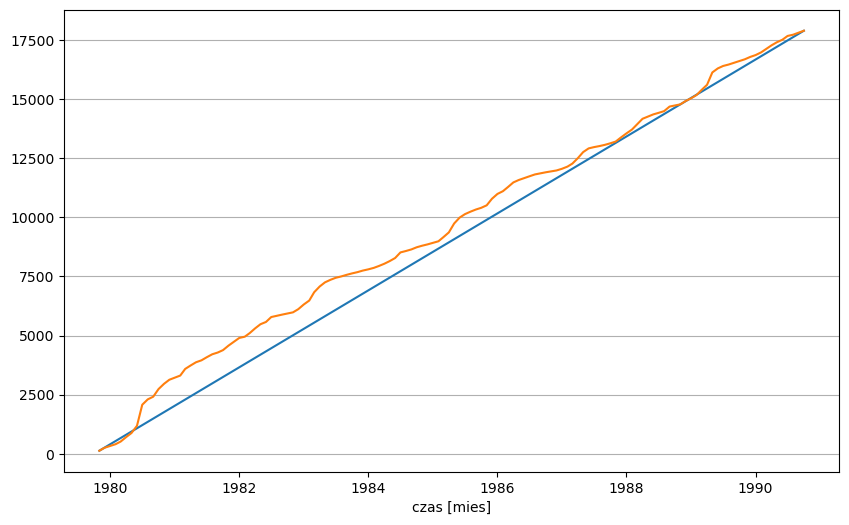

In [59]:
df['date'] = df['date'].apply(str_to_datetime)

x = df['date'].to_numpy()
y1 = df['V_sum'].to_numpy()
y2 = df['ss'].to_numpy()

plt.figure(figsize=(10,6))
plt.plot(x,y2)
plt.plot(x,y1)
plt.grid(axis = 'y')
plt.xlabel("czas [mies]")
#plt.legend(["H [cm]","Q [$m^3/s$]"])

#years = plt.matplotlib.dates.YearLocator()
#ax.xaxis.set_major_locator(years)
#ax.format_xdata = plt.matplotlib.dates.DateFormatter('%Y')

plt.show()

Text(0.5, 0, 'czas [mies]')

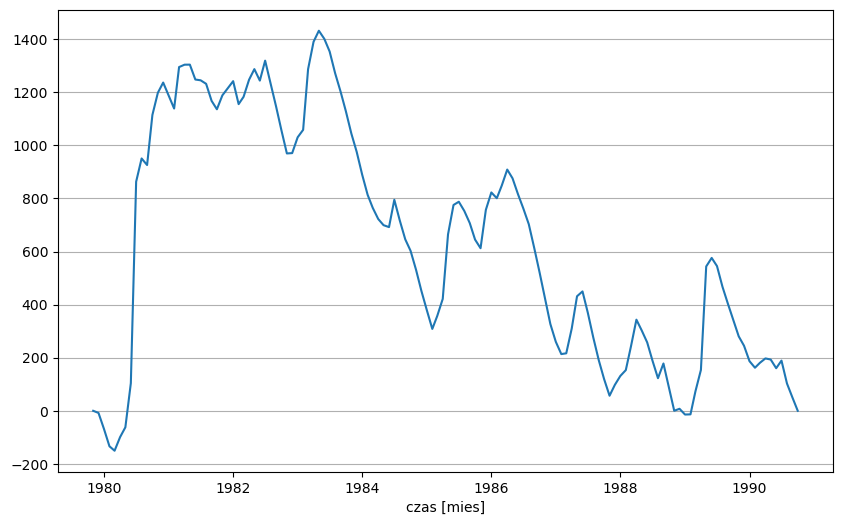

In [60]:
x = df['date'].to_numpy()
y1 = df['uu'].to_numpy()
#y2 = df['ss'].to_numpy()
plt.figure(figsize=(10,6))
plt.plot(x,y1)
#plt.plot(x,y2)
plt.grid(axis = 'y')
#plt.legend(["H [cm]","Q [$m^3/s$]"])
plt.xlabel("czas [mies]")